Bu projenin amacı, kredi başvurusu yapan müşterilerin kredi geri ödeme riskini tahmin eden bir makine öğrenmesi sınıflandırma modeli geliştirmektir. Finansal kurum, kredi başvurusu yapan müşteriler arasından temerrüde/default’a düşme ihtimali düşük olan iyi müşterileri belirlemek istemektedir.

Bu nedenle proje kapsamında müşterilere ait demografik, finansal ve kredi geçmişi bilgileri kullanılarak bir tahmin modeli oluşturulmuştur. Modelin temel hedefi, müşterinin kredi için uygun olup olmadığını veya kredi geri ödeme açısından düşük riskli olup olmadığını tahmin etmektir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)

import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")

In [2]:
df = pd.read_csv('loansTrainingSet.csv')

In [3]:
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,000025bb-5694-4cff-b17d-192b1a98ba44,5ebc8bb1-5eb9-4404-b11b-a6eebc401a19,Fully Paid,11520,Short Term,741.0,10+ years,Home Mortgage,33694.0,Debt Consolidation,$584.03,12.3,41.0,10,0,6760,16056,0.0,0.0
1,00002c49-3a29-4bd4-8f67-c8f8fbc1048c,927b388d-2e01-423f-a8dc-f7e42d668f46,Fully Paid,3441,Short Term,734.0,4 years,Home Mortgage,42269.0,other,"$1,106.04",26.3,NaN,17,0,6262,19149,0.0,0.0
2,00002d89-27f3-409b-aa76-90834f359a65,defce609-c631-447d-aad6-1270615e89c4,Fully Paid,21029,Short Term,747.0,10+ years,Home Mortgage,90126.0,Debt Consolidation,"$1,321.85",28.8,NaN,5,0,20967,28335,0.0,0.0
3,00005222-b4d8-45a4-ad8c-186057e24233,070bcecb-aae7-4485-a26a-e0403e7bb6c5,Fully Paid,18743,Short Term,747.0,10+ years,Own Home,38072.0,Debt Consolidation,$751.92,26.2,NaN,9,0,22529,43915,0.0,0.0
4,0000757f-a121-41ed-b17b-162e76647c1f,dde79588-12f0-4811-bab0-e2b07f633fcd,Fully Paid,11731,Short Term,746.0,4 years,Rent,50025.0,Debt Consolidation,$355.18,11.5,NaN,12,0,17391,37081,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256984 entries, 0 to 256983
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       256984 non-null  object 
 1   Customer ID                   256984 non-null  object 
 2   Loan Status                   256984 non-null  object 
 3   Current Loan Amount           256984 non-null  int64  
 4   Term                          256984 non-null  object 
 5   Credit Score                  195308 non-null  float64
 6   Years in current job          245508 non-null  object 
 7   Home Ownership                256984 non-null  object 
 8   Annual Income                 195308 non-null  float64
 9   Purpose                       256984 non-null  object 
 10  Monthly Debt                  256984 non-null  object 
 11  Years of Credit History       256984 non-null  float64
 12  Months since last delinquent  116601 non-nul

In [5]:
df.isnull().sum()

Loan ID                              0
Customer ID                          0
Loan Status                          0
Current Loan Amount                  0
Term                                 0
Credit Score                     61676
Years in current job             11476
Home Ownership                       0
Annual Income                    61676
Purpose                              0
Monthly Debt                         0
Years of Credit History              0
Months since last delinquent    140383
Number of Open Accounts              0
Number of Credit Problems            0
Current Credit Balance               0
Maximum Open Credit                  0
Bankruptcies                       529
Tax Liens                           23
dtype: int64

In [6]:
df.describe(include="all")

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,256984,256984,256984,2.569840e+05,256984,195308.000000,245508,256984,1.953080e+05,256984,256984,256984.000000,116601.000000,256984.000000,256984.000000,2.569840e+05,256984.0,256455.000000,256961.000000
unique,215700,215700,2,NaN,2,NaN,11,4,NaN,10,129115,NaN,NaN,NaN,NaN,NaN,87188.0,NaN,NaN
top,3f6bd37a-b0bc-4d85-93c7-eea53df601fb,a96104f4-2f44-4112-82b9-75605d44dac3,Fully Paid,NaN,Short Term,NaN,10+ years,Home Mortgage,NaN,Debt Consolidation,$0.00,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
freq,4,4,176191,NaN,192632,NaN,78896,124477,NaN,203911,254,NaN,NaN,NaN,NaN,NaN,1597.0,NaN,NaN
mean,NaN,NaN,NaN,1.371331e+07,NaN,1251.116099,NaN,NaN,7.195272e+04,NaN,NaN,18.290195,34.881450,11.106267,0.156628,1.540656e+04,NaN,0.110316,0.027203
std,NaN,NaN,NaN,3.438131e+07,NaN,1762.016848,NaN,NaN,5.887757e+04,NaN,NaN,7.075747,21.854165,4.982982,0.460731,1.966506e+04,NaN,0.336229,0.245950
min,NaN,NaN,NaN,5.050000e+02,NaN,585.000000,NaN,NaN,0.000000e+00,NaN,NaN,3.400000,0.000000,0.000000,0.000000,0.000000e+00,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,8.299000e+03,NaN,714.000000,NaN,NaN,4.432100e+04,NaN,NaN,13.500000,16.000000,8.000000,0.000000,5.974000e+03,NaN,0.000000,0.000000
50%,NaN,NaN,NaN,1.429800e+04,NaN,733.000000,NaN,NaN,6.124200e+04,NaN,NaN,17.000000,32.000000,10.000000,0.000000,1.107800e+04,NaN,0.000000,0.000000
75%,NaN,NaN,NaN,2.436700e+04,NaN,744.000000,NaN,NaN,8.646200e+04,NaN,NaN,21.700000,51.000000,14.000000,0.000000,1.931900e+04,NaN,0.000000,0.000000


In [7]:
df.corr(numeric_only=True)

,Current Loan Amount,Credit Score,Annual Income,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Bankruptcies,Tax Liens
Current Loan Amount,1.000000,-0.139743,0.024069,0.014725,0.003488,-0.003094,-0.000062,0.003138,0.003576,-0.003069
Credit Score,-0.139743,1.000000,-0.033221,-0.011658,-0.007994,0.008124,0.000777,-0.003263,-0.003426,0.004381
Annual Income,0.024069,-0.033221,1.000000,0.146859,-0.059675,0.140463,-0.013672,0.292165,-0.044837,0.038185
Years of Credit History,0.014725,-0.011658,0.146859,1.000000,-0.039695,0.128033,0.061251,0.201001,0.062049,0.020915
Months since last delinquent,0.003488,-0.007994,-0.059675,-0.039695,1.000000,-0.035803,0.088612,-0.024292,0.112907,0.002730
Number of Open Accounts,-0.003094,0.008124,0.140463,0.128033,-0.035803,1.000000,-0.013731,0.222763,-0.022805,0.005754
Number of Credit Problems,-0.000062,0.000777,-0.013672,0.061251,0.088612,-0.013731,1.000000,-0.103814,0.755866,0.584917
Current Credit Balance,0.003138,-0.003263,0.292165,0.201001,-0.024292,0.222763,-0.103814,1.000000,-0.117995,-0.011118
Bankruptcies,0.003576,-0.003426,-0.044837,0.062049,0.112907,-0.022805,0.755866,-0.117995,1.000000,0.046160
Tax Liens,-0.003069,0.004381,0.038185,0.020915,0.002730,0.005754,0.584917,-0.011118,0.046160,1.000000


In [8]:
df.duplicated().sum()

np.int64(16610)

<Axes: >

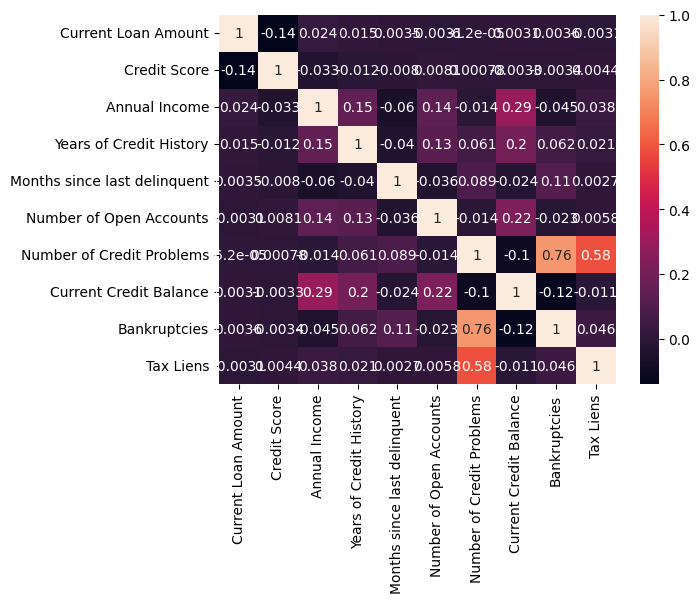

In [9]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: >

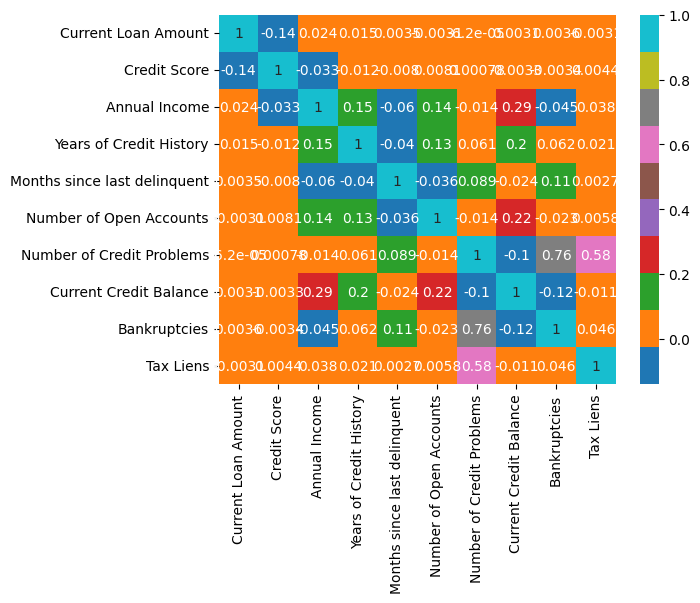

In [10]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='tab10')

In [11]:
def clean_column_name(col):
    col = col.strip().lower()
    col = re.sub(r"[^a-zA-Z0-9]+", "_", col)
    col = col.strip("_")
    return col

df.columns = [clean_column_name(col) for col in df.columns]

df.head()

,loan_id,customer_id,loan_status,current_loan_amount,term,credit_score,years_in_current_job,home_ownership,annual_income,purpose,monthly_debt,years_of_credit_history,months_since_last_delinquent,number_of_open_accounts,number_of_credit_problems,current_credit_balance,maximum_open_credit,bankruptcies,tax_liens
0,000025bb-5694-4cff-b17d-192b1a98ba44,5ebc8bb1-5eb9-4404-b11b-a6eebc401a19,Fully Paid,11520,Short Term,741.0,10+ years,Home Mortgage,33694.0,Debt Consolidation,$584.03,12.3,41.0,10,0,6760,16056,0.0,0.0
1,00002c49-3a29-4bd4-8f67-c8f8fbc1048c,927b388d-2e01-423f-a8dc-f7e42d668f46,Fully Paid,3441,Short Term,734.0,4 years,Home Mortgage,42269.0,other,"$1,106.04",26.3,NaN,17,0,6262,19149,0.0,0.0
2,00002d89-27f3-409b-aa76-90834f359a65,defce609-c631-447d-aad6-1270615e89c4,Fully Paid,21029,Short Term,747.0,10+ years,Home Mortgage,90126.0,Debt Consolidation,"$1,321.85",28.8,NaN,5,0,20967,28335,0.0,0.0
3,00005222-b4d8-45a4-ad8c-186057e24233,070bcecb-aae7-4485-a26a-e0403e7bb6c5,Fully Paid,18743,Short Term,747.0,10+ years,Own Home,38072.0,Debt Consolidation,$751.92,26.2,NaN,9,0,22529,43915,0.0,0.0
4,0000757f-a121-41ed-b17b-162e76647c1f,dde79588-12f0-4811-bab0-e2b07f633fcd,Fully Paid,11731,Short Term,746.0,4 years,Rent,50025.0,Debt Consolidation,$355.18,11.5,NaN,12,0,17391,37081,0.0,0.0


In [12]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

In [13]:
print("Silinen duplicate satır sayısı:", before - after)

Silinen duplicate satır sayısı: 16610


In [14]:
cols = df.select_dtypes("object").columns

df[cols] = df[cols].apply(lambda x: x.astype(str).str.strip().str.lower()).replace({
    "nan": np.nan, "none": np.nan, "null": np.nan, "": np.nan,
    "y": "yes", "n": "no",
    "m": "male", "f": "female",
    "not graduate": "not_graduate",
    "not_graduated": "not_graduate"
})

In [15]:
def conv(s):
    y = pd.to_numeric(s.astype(str).str.strip().str.replace(r"[,$%+]", "", regex=True), errors="coerce")
    return y if y.notna().mean() >= .7 else s

df[df.select_dtypes("object").columns] = df.select_dtypes("object").apply(conv)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240374 entries, 0 to 256983
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   loan_id                       240374 non-null  object 
 1   customer_id                   240374 non-null  object 
 2   loan_status                   240374 non-null  object 
 3   current_loan_amount           240374 non-null  int64  
 4   term                          240374 non-null  object 
 5   credit_score                  181028 non-null  float64
 6   years_in_current_job          229930 non-null  object 
 7   home_ownership                240374 non-null  object 
 8   annual_income                 181028 non-null  float64
 9   purpose                       240374 non-null  object 
 10  monthly_debt                  240374 non-null  float64
 11  years_of_credit_history       240374 non-null  float64
 12  months_since_last_delinquent  108947 non-null  fl

In [17]:
df.columns

Index(['loan_id', 'customer_id', 'loan_status', 'current_loan_amount', 'term',
       'credit_score', 'years_in_current_job', 'home_ownership',
       'annual_income', 'purpose', 'monthly_debt', 'years_of_credit_history',
       'months_since_last_delinquent', 'number_of_open_accounts',
       'number_of_credit_problems', 'current_credit_balance',
       'maximum_open_credit', 'bankruptcies', 'tax_liens'],
      dtype='object')

In [18]:
target_col = next((c for c in ["loan_status","default","status","target"] if c in df.columns), None)
print("Hedef sütun:", target_col)

Hedef sütun: loan_status


In [19]:
df[target_col].value_counts(dropna=False)

loan_status
fully paid     176191
charged off     64183
Name: count, dtype: int64

In [20]:
df.duplicated().sum()

np.int64(1)

In [21]:
df.drop_duplicates()

,loan_id,customer_id,loan_status,current_loan_amount,term,credit_score,years_in_current_job,home_ownership,annual_income,purpose,monthly_debt,years_of_credit_history,months_since_last_delinquent,number_of_open_accounts,number_of_credit_problems,current_credit_balance,maximum_open_credit,bankruptcies,tax_liens
0,000025bb-5694-4cff-b17d-192b1a98ba44,5ebc8bb1-5eb9-4404-b11b-a6eebc401a19,fully paid,11520,short term,741.0,10+ years,home mortgage,33694.0,debt consolidation,584.03,12.3,41.0,10,0,6760,16056.0,0.0,0.0
1,00002c49-3a29-4bd4-8f67-c8f8fbc1048c,927b388d-2e01-423f-a8dc-f7e42d668f46,fully paid,3441,short term,734.0,4 years,home mortgage,42269.0,other,1106.04,26.3,NaN,17,0,6262,19149.0,0.0,0.0
2,00002d89-27f3-409b-aa76-90834f359a65,defce609-c631-447d-aad6-1270615e89c4,fully paid,21029,short term,747.0,10+ years,home mortgage,90126.0,debt consolidation,1321.85,28.8,NaN,5,0,20967,28335.0,0.0,0.0
3,00005222-b4d8-45a4-ad8c-186057e24233,070bcecb-aae7-4485-a26a-e0403e7bb6c5,fully paid,18743,short term,747.0,10+ years,own home,38072.0,debt consolidation,751.92,26.2,NaN,9,0,22529,43915.0,0.0,0.0
4,0000757f-a121-41ed-b17b-162e76647c1f,dde79588-12f0-4811-bab0-e2b07f633fcd,fully paid,11731,short term,746.0,4 years,rent,50025.0,debt consolidation,355.18,11.5,NaN,12,0,17391,37081.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256979,fffef5b7-be99-4666-ac70-2a397d2ee435,7211a8e3-cba4-4132-b939-222eed8a662c,fully paid,3911,short term,NaN,2 years,rent,NaN,debt consolidation,1706.58,19.9,NaN,16,0,43992,44080.0,0.0,0.0
256980,ffffca93-aa8c-4123-b8ff-7852f6df889a,616fef0c-8f09-4327-9b5c-48fcfaa52934,fully paid,5078,short term,737.0,10+ years,own home,77186.0,debt consolidation,1376.47,19.1,47.0,9,0,1717,9758.0,0.0,0.0
256981,ffffcb2e-e48e-4d2c-a0d6-ed6bce5bfdbe,971a6682-183b-4a52-8bce-1d3429ade295,charged off,12116,short term,7460.0,9 years,home mortgage,52504.0,debt consolidation,297.96,15.1,82.0,8,0,3315,20090.0,0.0,0.0
256982,ffffcb2e-e48e-4d2c-a0d6-ed6bce5bfdbe,971a6682-183b-4a52-8bce-1d3429ade295,charged off,12116,short term,746.0,9 years,home mortgage,52504.0,debt consolidation,297.96,15.1,82.0,8,0,3315,20090.0,0.0,0.0


In [22]:
if "default" in target_col:
    df["good_customer"] = 1 - df[target_col].astype(int)
    target = "good_customer"
else:
    target = target_col

In [23]:
drop_cols = list(({target_col, target} - {None}) | {c for c in df.columns if "id" in c.lower()})
drop_cols

['loan_id', 'customer_id', 'loan_status']

In [24]:
X = df.drop(columns=drop_cols)
y = df[target]

In [25]:
sensitive_cols = ["gender"]

for col in sensitive_cols:
    if col in X.columns:
        X = X.drop(columns=col)

In [26]:
X.columns

Index(['current_loan_amount', 'term', 'credit_score', 'years_in_current_job',
       'home_ownership', 'annual_income', 'purpose', 'monthly_debt',
       'years_of_credit_history', 'months_since_last_delinquent',
       'number_of_open_accounts', 'number_of_credit_problems',
       'current_credit_balance', 'maximum_open_credit', 'bankruptcies',
       'tax_liens'],
      dtype='object')

In [27]:
def find_col(columns, possible_names):
    for name in possible_names:
        if name in columns:
            return name
    return None

In [28]:
app_income_col = find_col(X.columns, ["applicantincome", "applicant_income"])
coapp_income_col = find_col(X.columns, ["coapplicantincome", "coapplicant_income"])
loan_amount_col = find_col(X.columns, ["loanamount", "loan_amount"])
loan_term_col = find_col(X.columns, ["loan_amount_term", "loanterm", "loan_term"])

In [29]:
if app_income_col and coapp_income_col: X["total_income"] = X[app_income_col] + X[coapp_income_col]
if loan_amount_col and "total_income" in X: X["loan_to_income_ratio"] = X[loan_amount_col] / (X["total_income"] + 1)
if coapp_income_col and "total_income" in X: X["coapplicant_income_ratio"] = X[coapp_income_col] / (X["total_income"] + 1)
if loan_amount_col and loan_term_col: X["monthly_loan_amount"] = X[loan_amount_col] / (X[loan_term_col] + 1)
if "monthly_loan_amount" in X and "total_income" in X: X["monthly_payment_to_income"] = X["monthly_loan_amount"] / (X["total_income"] + 1)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)

In [31]:
print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (192299, 16) X_test: (48075, 16)


In [32]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

In [33]:
for col in numeric_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

In [34]:
X_train.isnull().sum().sum(), X_test.isnull().sum().sum()

(np.int64(8345), np.int64(2099))

In [35]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

In [36]:
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [37]:
X_train_encoded.shape, X_test_encoded.shape

((192299, 34), (48075, 34))

In [38]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_encoded, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
y_pred = model.predict(X_test_encoded)
y_proba = model.predict_proba(X_test_encoded)[:, 1]

In [40]:
y_pred

array(['charged off', 'fully paid', 'fully paid', ..., 'charged off',
       'fully paid', 'charged off'], shape=(48075,), dtype=object)

In [41]:
y_proba

array([0.17001543, 0.77600213, 0.50835319, ..., 0.21397693, 0.54072722,
       0.49780989], shape=(48075,))

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

 charged off       0.48      0.66      0.55     12837
  fully paid       0.86      0.73      0.79     35238

    accuracy                           0.71     48075
   macro avg       0.67      0.70      0.67     48075
weighted avg       0.76      0.71      0.73     48075



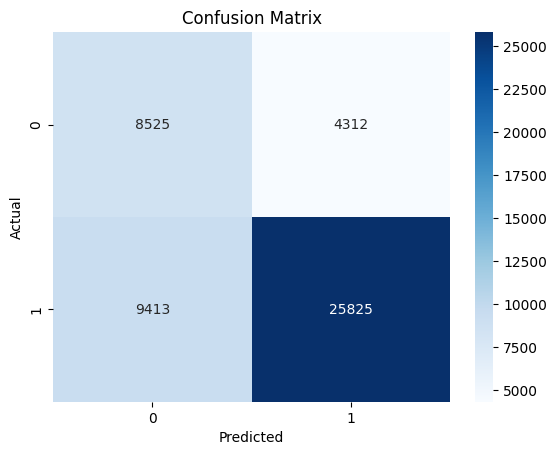

In [43]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
results = pd.DataFrame(index=X_test.index)

results["actual"] = y_test
results["predicted_good_customer"] = y_pred
results["good_customer_probability"] = y_proba

results.head()

,actual,predicted_good_customer,good_customer_probability
66875,charged off,charged off,0.170015
218813,fully paid,fully paid,0.776002
198249,fully paid,fully paid,0.508353
237852,fully paid,fully paid,0.535786
53499,fully paid,fully paid,0.574119


In [45]:
good_customers = results[results["predicted_good_customer"] == 1]

good_customers.sort_values(
    by="good_customer_probability",
    ascending=False
).head(10)

,actual,predicted_good_customer,good_customer_probability


In [46]:
risky_customers = results[results["predicted_good_customer"] == 0]

risky_customers.sort_values(
    by="good_customer_probability",
    ascending=True
).head(10)

,actual,predicted_good_customer,good_customer_probability


In [47]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train_encoded.columns
).sort_values(ascending=False)

feature_importance.head(15)

credit_score                      0.453799
current_loan_amount               0.337688
term_short term                   0.115179
annual_income                     0.033977
maximum_open_credit               0.015327
home_ownership_home mortgage      0.009988
home_ownership_rent               0.008313
years_of_credit_history           0.005902
monthly_debt                      0.005462
current_credit_balance            0.005085
number_of_open_accounts           0.002677
months_since_last_delinquent      0.002421
purpose_buy a car                 0.000803
years_in_current_job_10+ years    0.000506
home_ownership_own home           0.000453
dtype: float64

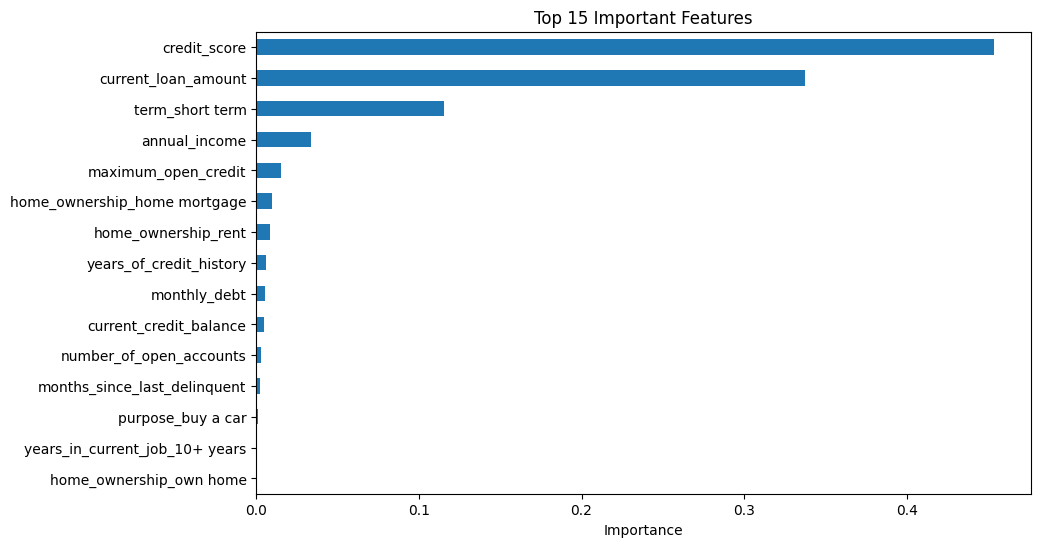

In [48]:
plt.figure(figsize=(10, 6))
feature_importance.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.show()

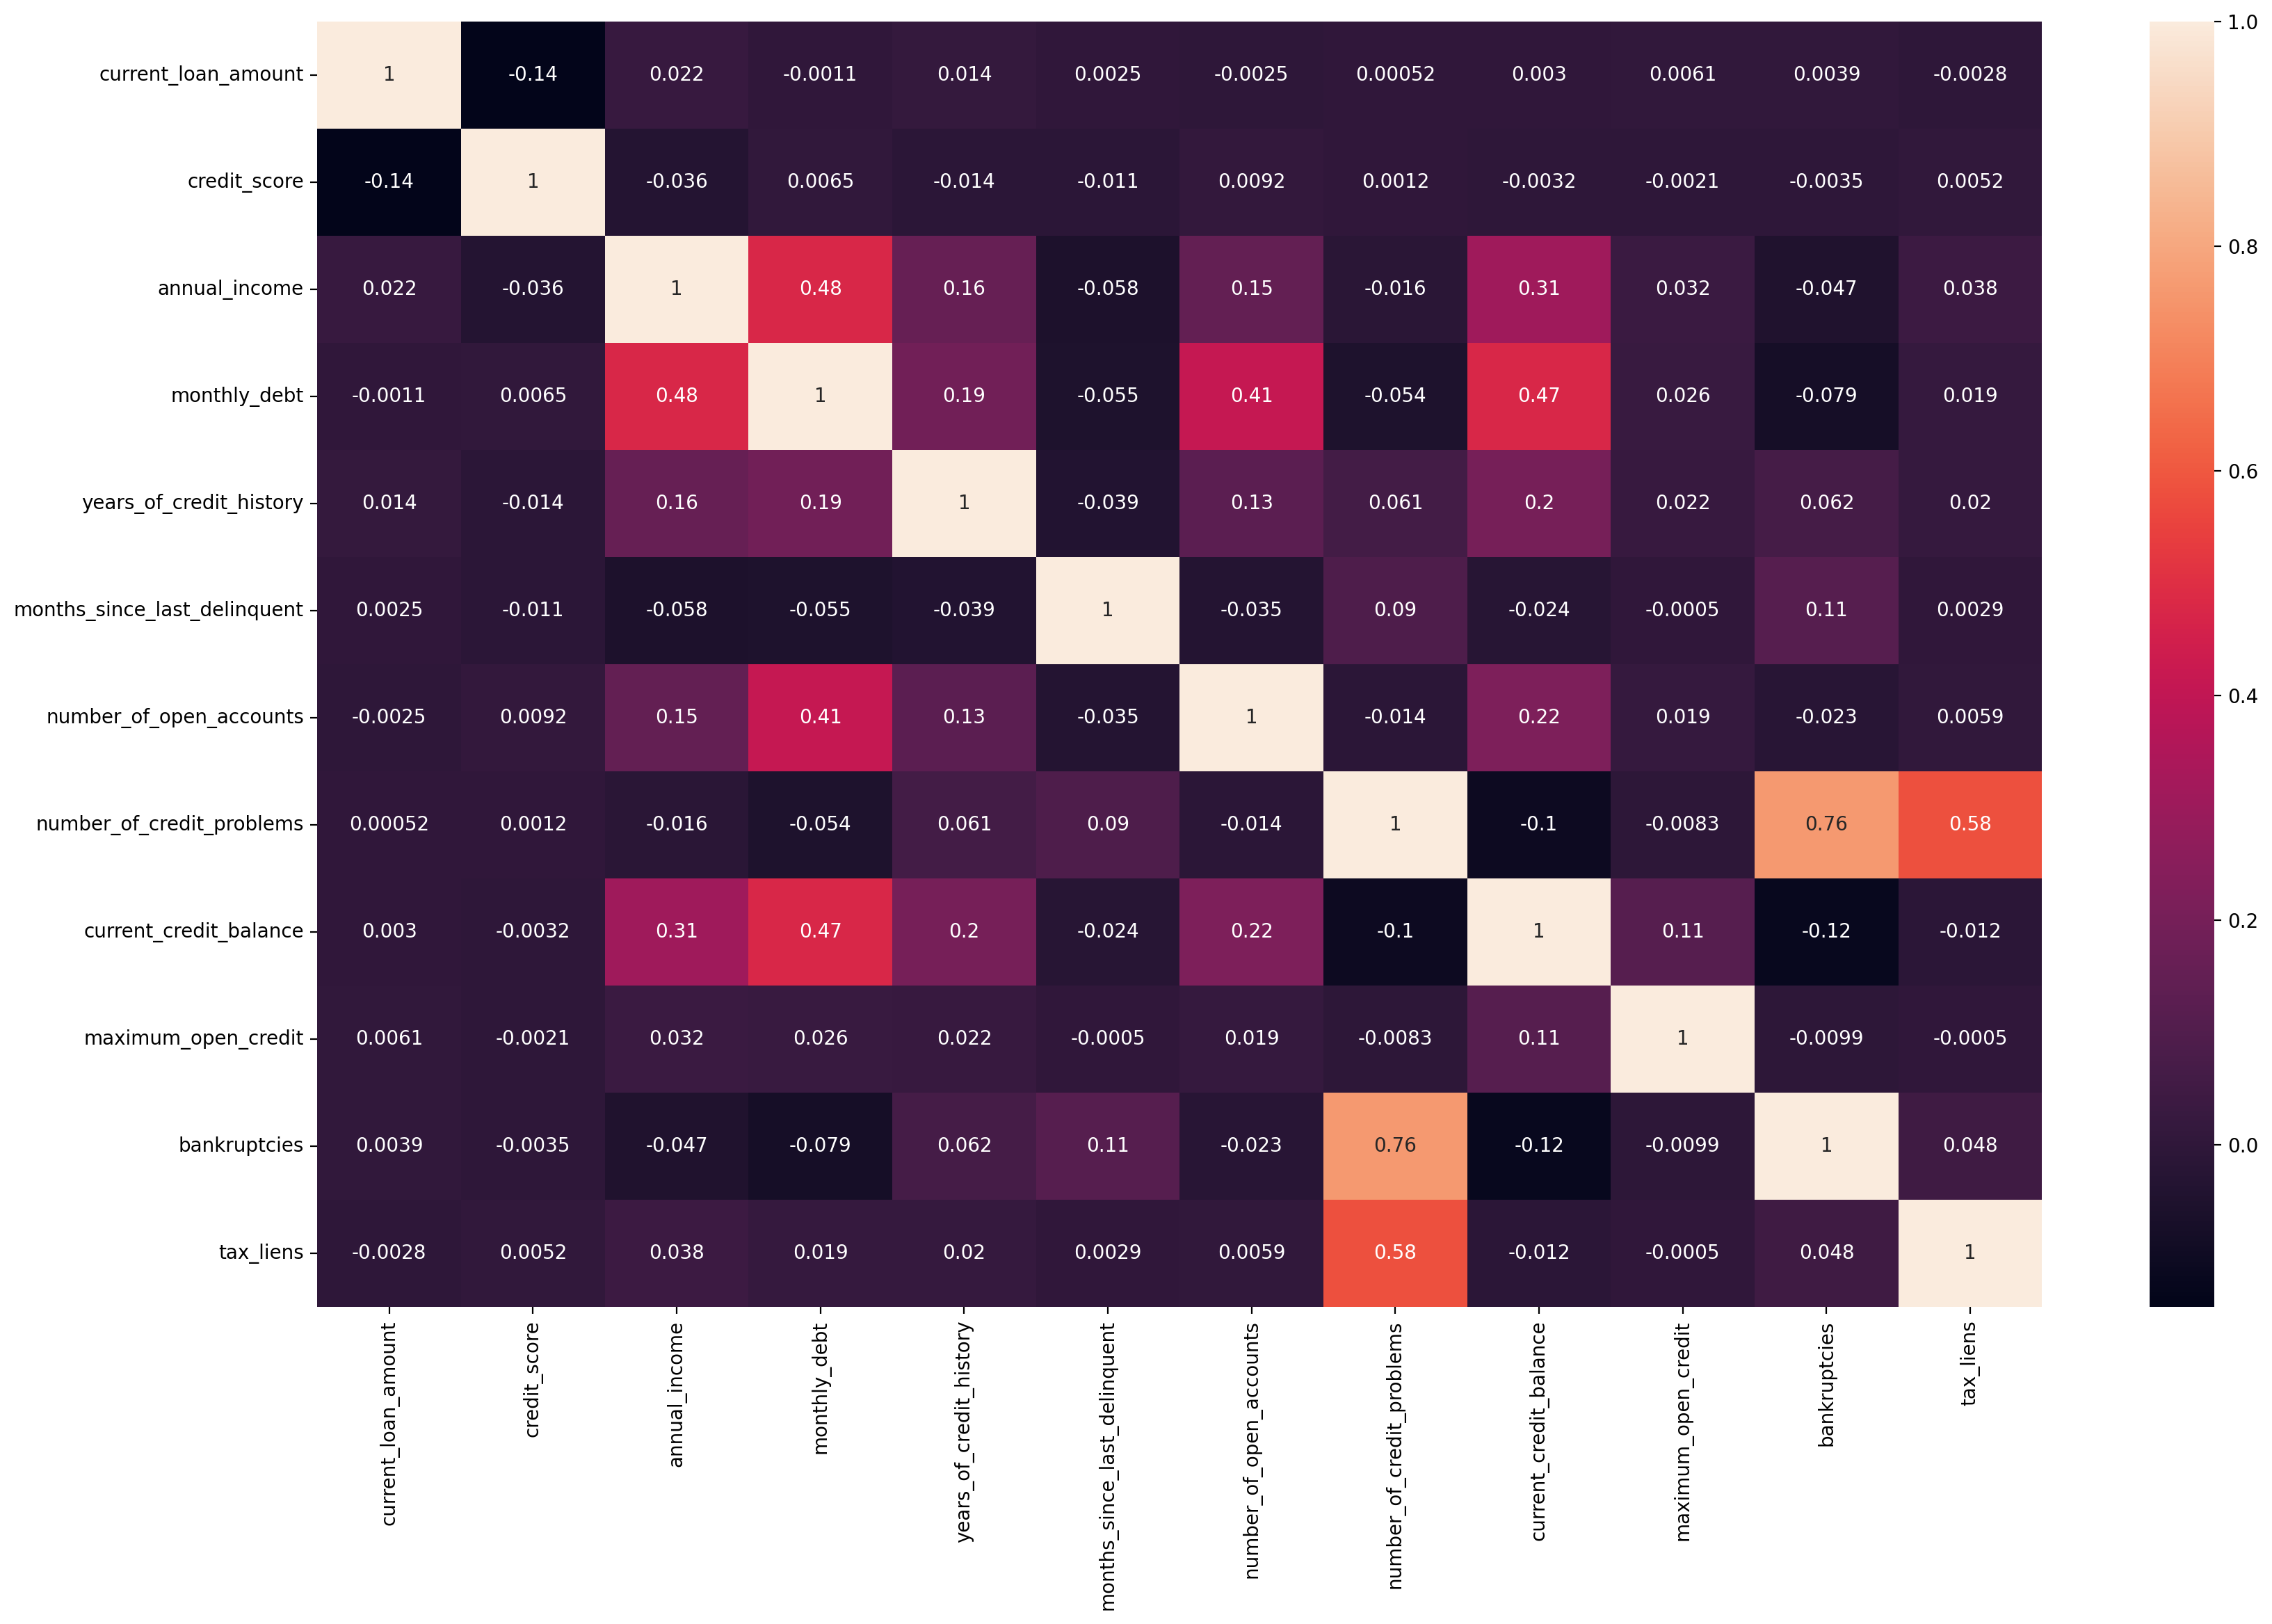

In [50]:
plt.figure(figsize=(20,12), dpi=200)
sns.heatmap(df.select_dtypes("number").corr(), annot=True)
plt.show()

Bu proje kapsamında kredi başvurusu yapan müşterilerin kredi geri ödeme açısından iyi müşteri olup olmadığını tahmin etmek için bir sınıflandırma modeli geliştirilmiştir.

Proje sürecinde:

Veri okunmuş ve incelenmiştir.
Eksik ve hatalı değerler temizlenmiştir.
Kategorik değişkenler sayısallaştırılmıştır.
Yeni finansal oranlar üretilmiştir.
Veri eğitim ve test olarak ayrılmıştır.
Sınıflandırma modeli eğitilmiştir.
Model performansı değerlendirilmiştir.
Model sonucuna göre müşteri başvuru soruları oluşturulmuştur.
Sonuç olarak bu proje, finansal kurumların kredi başvurularını daha hızlı, daha objektif ve daha düşük riskle değerlendirmesine yardımcı olabilecek bir makine öğrenmesi çözümüdür.